<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Computer Vision



In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.9.0+cu126
0.24.0+cu126


## 1. Getting a dataset

In [2]:
train_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor(), target_transform=None)
test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor(), target_transform=None)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]


In [3]:
class_names = train_data.classes

In [4]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [5]:
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

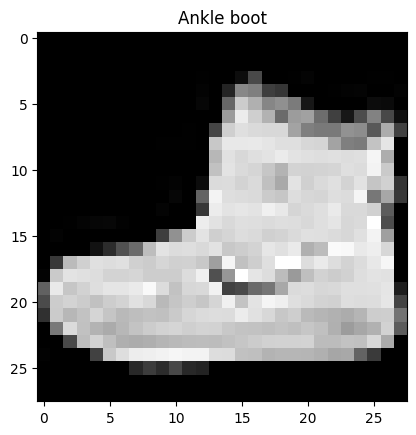

In [6]:
# visualizing our data

image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

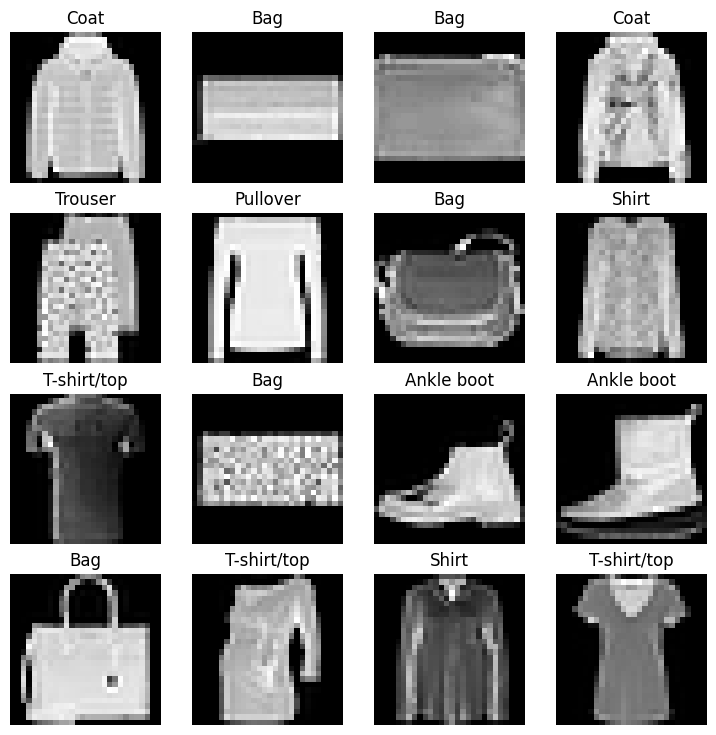

In [7]:
# plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False);

In [8]:
# prepare DataLoader


In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

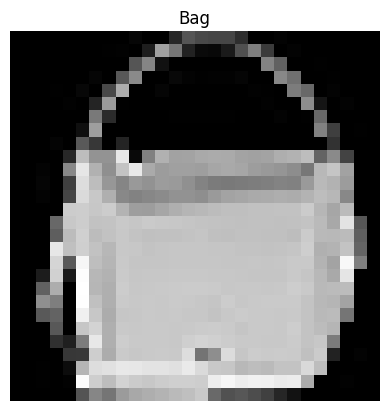

In [11]:
# show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False);

## 3 Model 0: Build a basline model

In [12]:
# create a flatten layer
flatten_model = nn.Flatten()

# get a single sample
x = train_features_batch[0] # -> [channel, height, width]
output = flatten_model(x)   # -> [channel, height*width]

In [13]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
  def forward(self, x):
    return self.layer_stack(x)

torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names)).to("cpu")

In [14]:
dummy_x = torch.randn([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.2228,  0.1477,  0.3137, -0.3110, -0.3713,  0.0156,  0.4363,  0.1060,
         -0.1604, -0.4388]], grad_fn=<AddmmBackward0>)

### 3. 1 Setup loss, optimizer, and evaluation metrics

In [15]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

In [16]:
# accuracy
from helper_functions import accuracy_fn

# loss function and optimzier
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.01)

### 3.2 Creating a function to time our experiments

In [17]:
from time import time

start = time()
end = time()

def train_time(start, end):
  return round(end-start, 3)

train_time(start, end)

0.0

In [18]:
from tqdm.auto import tqdm

torch.manual_seed(42)

start = time()
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n----")
  train_loss = 0
  for batch, (X, y) in enumerate(train_dataloader):
    # train
    model_0.train()
    y_pred = model_0(X)
    # loss
    loss = loss_fn(y_pred, y)
    train_loss += loss
    # zero grad
    optimizer.zero_grad()
    # back propagation
    loss.backward()
    # optimizer step
    optimizer.step()

    if batch % 400 == 0:
      print(f"Look at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  # divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  # test
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # forward pass
      test_pred = model_0(X_test)
      # caluclate loss (accumulatively)
      test_loss += loss_fn(test_pred, y_test)
      # accuracy
      test_acc += accuracy_fn(y_test, test_pred.argmax(dim=1))
    # calculate test loss per batch
    test_loss /= len(test_dataloader)
    # calculate accuracy per batch
    test_acc /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.3f} | Test loss: {test_loss:.3f} | Test accuracy {test_acc:.3f}")

end = time()
total_train_time_model_0 = train_time(start, end)
print(train_time(start, end))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples

Train loss: 0.910 | Test loss: 0.629 | Test accuracy 78.634
Epoch: 1
----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples

Train loss: 0.557 | Test loss: 0.544 | Test accuracy 81.130
Epoch: 2
----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples

Train loss: 0.503 | Test loss: 0.514 | Test accuracy 81.999
25.497


## 4. Make predictions and get Model 0 results

In [19]:
# device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [20]:
from sklearn.metrics import accuracy_score

torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      # make predictions
      y_pred = model(X)
      # loss and acc per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    # scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc  /= len(data_loader)


  return {"model_name" : model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

model_0_results = eval_model(model_0, test_dataloader, loss_fn, accuracy_fn, device="cpu")
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5136752128601074,
 'model_acc': 81.9988019169329}

## 6. Model 1: Building a better model with non-linearity

In [21]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
        )
  def forward(self, x: torch.tensor):
    return self.layer_stack(x)

torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names)).to(device)

In [22]:
# loss function and optimzier
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01)

In [23]:
# make train step function
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device=device):
    model.to(device)
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(data_loader):
      X, y = X.to(device), y.to(device) # put data to deice
      y_pred = model(X)                 # forward pass
      loss = loss_fn(y_pred, y)         # loss function
      train_loss += loss
      train_acc += accuracy_fn(y, y_pred.argmax(dim=1)) # .argmac(dim=1) change from probability to label
      optimizer.zero_grad()             # zeroed the optimizer
      loss.backward()                   # back propagation
      optimizer.step()                  # the optimizer
    train_loss /= len(data_loader)
    train_acc  /= len(data_loader)
    print(f"Train loss: {train_loss:.3f} | Train accuracy: {train_acc:.3f}%")

def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device=device):
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X, y in test_dataloader:
      X, y = X.to(device), y.to(device) # put data to deice
      test_pred = model(X)       # forward pass
      test_loss += loss_fn(test_pred, y) # caluclate loss (accumulatively)
      test_acc += accuracy_fn(y, test_pred.argmax(dim=1)) # accuracy
    test_loss /= len(test_dataloader) # calculate test loss per batch
    test_acc /= len(test_dataloader) # calculate accuracy per batch
  print(f"Test loss: {test_loss:.3f} | Test accuracy {test_acc:.3f}%")

In [24]:
epochs = 3
start = time()
for epoch in tqdm(range(epochs)):
  print(f"------------ \nEpoch: {epoch}")
  train_step(model_1, train_dataloader, loss_fn, optimizer, accuracy_fn)
  test_step(model_1, test_dataloader, loss_fn, optimizer, accuracy_fn)
end = time()
total_train_time_model_1 = train_time(start, end)
print(train_time(start, end))

  0%|          | 0/3 [00:00<?, ?it/s]

------------ 
Epoch: 0
Train loss: 1.430 | Train accuracy: 53.817%
Test loss: 1.126 | Test accuracy 61.122%
------------ 
Epoch: 1
Train loss: 1.033 | Train accuracy: 64.743%
Test loss: 0.998 | Test accuracy 64.826%
------------ 
Epoch: 2
Train loss: 0.960 | Train accuracy: 66.030%
Test loss: 0.961 | Test accuracy 65.455%
29.74


In [25]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      # make predictions
      y_pred = model(X)
      # loss and acc per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    # scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc  /= len(data_loader)


  return {"model_name" : model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.9608813524246216,
 'model_acc': 65.45527156549521}

## Model 2: Building a Convolutional Neural Netweork (CNN)

In [26]:
class CnnModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)

    )
  def forward(self, x):
    x = self.conv_1(x)
    # print(x.shape)
    x = self.conv_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x

In [27]:
torch.manual_seed(42)
model_2 = CnnModel(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
model_2

CnnModel(
  (conv_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 7.1 Stepping through `nn.Conv2d`

In [28]:
torch.manual_seed(42)

# images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
images.shape, test_image.shape

(torch.Size([32, 3, 64, 64]), torch.Size([3, 64, 64]))

In [29]:
# single conv2d layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=1, stride=3, padding=1)
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 22, 22])

### 7.2 Stepping through `MaxPool2d()`

In [30]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)

test_conv = conv_layer(test_image)
print(test_conv.shape)
test_pool = max_pool_layer(test_conv)
print(test_pool.shape)

torch.Size([10, 22, 22])
torch.Size([10, 11, 11])


In [31]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

start = time()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} \n----------")
  train_step(data_loader=train_dataloader,
             model=model_2,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             optimizer=optimizer,
             device=device)
  test_step(data_loader=train_dataloader,
             model=model_2,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
            optimizer=optimizer,
             device=device)

end = time()
total_train_time_model_2 = train_time(start, end)
print(train_time(start, end))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
----------
Train loss: 1.041 | Train accuracy: 62.357%
Test loss: 0.626 | Test accuracy 77.566%
Epoch: 1 
----------
Train loss: 0.551 | Train accuracy: 79.982%
Test loss: 0.535 | Test accuracy 79.083%
Epoch: 2 
----------
Train loss: 0.453 | Train accuracy: 83.703%
Test loss: 0.519 | Test accuracy 80.781%
39.486


In [32]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'CnnModel',
 'model_loss': 0.5194939970970154,
 'model_acc': 80.78075079872204}

### Compare model reults and training time

In [33]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                               model_1_results,
                               model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.513675,81.998802
1,FashionMNISTModelV1,0.960881,65.455272
2,CnnModel,0.519494,80.780751


In [34]:
compare_results["training time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2,]
compare_results

,model_name,model_loss,model_acc,training time
0,FashionMNISTModelV0,0.513675,81.998802,25.497
1,FashionMNISTModelV1,0.960881,65.455272,29.740
2,CnnModel,0.519494,80.780751,39.486


Text(0, 0.5, 'model')

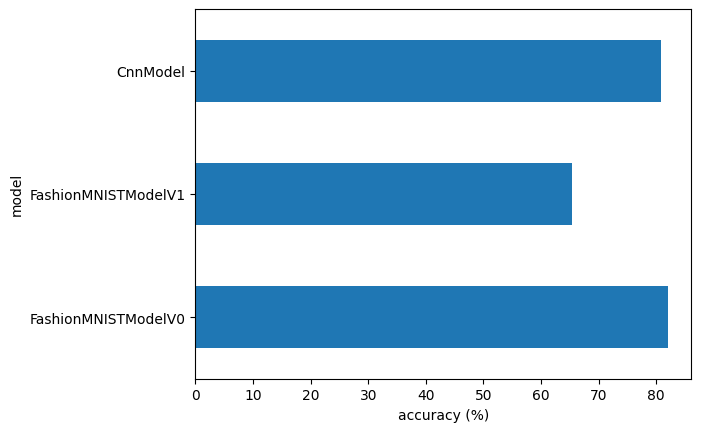

In [35]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

In [59]:
def make_predictions(model, data, device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [78]:
import random
# random.seed(42)
test_sample = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_sample.append(sample)
  test_labels.append(label)

test_sample[0].shape

torch.Size([1, 28, 28])

In [42]:
img, label = test_data[0][:10]
img.shape, label

(torch.Size([1, 28, 28]), 9)

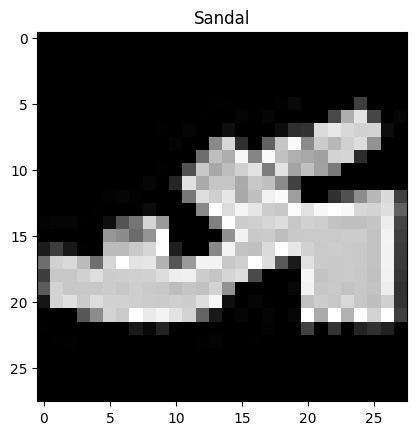

In [57]:
plt.imshow(test_sample[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]]);

In [79]:
# make predictions
pred_probs = make_predictions(model_2, test_sample)
pred_classes = pred_probs.argmax(dim=1) # convert probability to target
pred_classes

tensor([5, 2, 0, 1, 2, 2, 1, 4, 4])

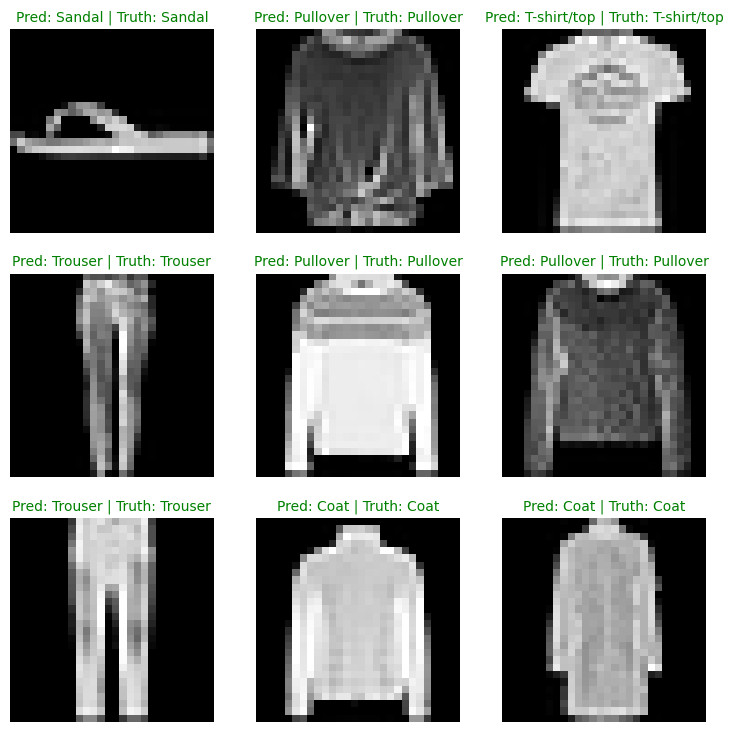

In [80]:
# plot [rediction
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_sample):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g")
  else:
    plt.title(title_text, fontsize=10, c="r")
  plt.axis(False)

## 10. Make a confusiom Matrix

In [85]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.0 MB/s eta 0:00:00


In [90]:
import mlxtend
from tqdm.auto import tqdm

# make prediction
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions..."):
    X, y = X.to(device), y.to(device)
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

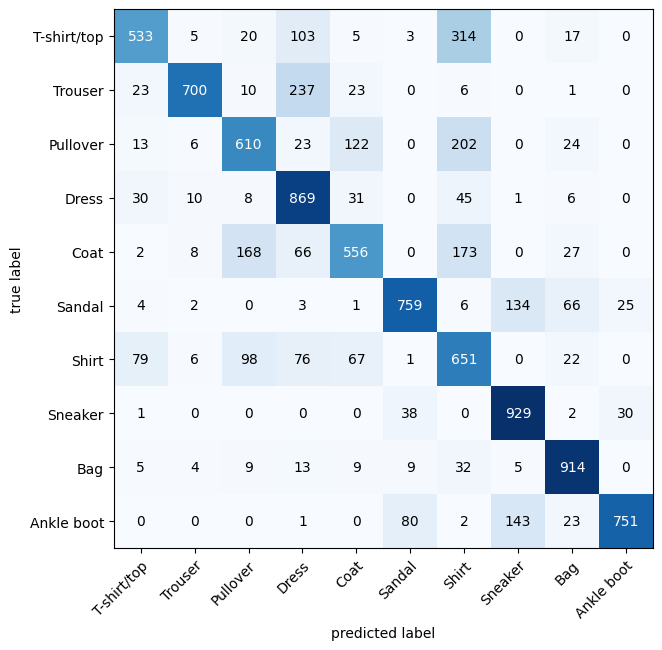

In [104]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)

)

## 11. Save and load bets perfroming model

In [109]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "03_pytorch_computer_vision_model_2.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pt


In [111]:
# load our model
loaded_model_2 = CnnModel(input_shape=1, hidden_units=10, output_shape=len(class_names))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)

CnnModel(
  (conv_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [112]:
model_2_results

{'model_name': 'CnnModel',
 'model_loss': 0.5194939970970154,
 'model_acc': 80.78075079872204}

In [116]:
# evaluate the loaded model
loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
)
loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'CnnModel',
 'model_loss': 0.5194939970970154,
 'model_acc': 80.78075079872204}

In [117]:
# check if a model close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-02)

tensor(True)